# 1. Importaciones

In [1]:
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# 2. Configuración

In [2]:
IMG_SIZE = (48,48)

BATCH_SIZE = 64

EPOCHS = 50

AUTOTUNE = tf.data.AUTOTUNE

# 3. Carga del Dataset

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(

    "datasets/Unified_Drowsiness_Dataset/train",

    color_mode="grayscale",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="binary",

    shuffle=True
)



val_ds = tf.keras.utils.image_dataset_from_directory(

    "datasets/Unified_Drowsiness_Dataset/val",

    color_mode="grayscale",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="binary",

    shuffle=False
)



test_ds = tf.keras.utils.image_dataset_from_directory(

    "datasets/Unified_Drowsiness_Dataset/test",

    color_mode="grayscale",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="binary",

    shuffle=False
)

Found 129696 files belonging to 2 classes.
Found 16212 files belonging to 2 classes.
Found 16216 files belonging to 2 classes.


In [4]:
print(train_ds.class_names)

['Drowsy', 'Natural']


# 4. Optimización del Pipeline

In [5]:
# 4. Optimización del Pipeline

train_ds = (
    train_ds
    .shuffle(5000)
    .prefetch(AUTOTUNE)
)


val_ds = (
    val_ds
    .prefetch(AUTOTUNE)
)


test_ds = (
    test_ds
    .prefetch(AUTOTUNE)
)

# 5. Data Augmentation

In [6]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomRotation(
        factor=0.05
    ),

    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )

])

# 6. Construcción del Modelo Optimizado

In [7]:
from tensorflow.keras.applications import MobileNetV3Small


# ==========================================
# MobileNetV3Small Transfer Learning
# ==========================================


input_layer = tf.keras.layers.Input(
    shape=(48,48,1)
)


# Adaptar tamaño

x = tf.keras.layers.Resizing(
    128,
    128
)(input_layer)



# convertir grayscale a RGB

x = tf.keras.layers.Concatenate()(
    [
        x,
        x,
        x
    ]
)



# ================================
# Modelo preentrenado
# ================================


base_model = MobileNetV3Small(

    input_shape=(128,128,3),

    include_top=False,

    weights="imagenet"

)



base_model.trainable = False



x = base_model(x)



# ================================
# Clasificador
# ================================


x = tf.keras.layers.GlobalAveragePooling2D()(x)



x = tf.keras.layers.Dropout(
    0.3
)(x)



x = tf.keras.layers.Dense(

    64,

    activation="relu"

)(x)



x = tf.keras.layers.Dropout(
    0.3
)(x)



output = tf.keras.layers.Dense(

    1,

    activation="sigmoid"

)(x)



model = tf.keras.Model(

    input_layer,

    output

)

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\applications\mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


# 7. Compilación con AdamW

In [8]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=1e-4
)

model.compile(

    optimizer=optimizer,

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

# 8. Resumen

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ resizing[0][0],   │
│ (Concatenate)       │ 3)                │            │ resizing[0][0],   │
│                     │                   │            │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Small    │ (None, 4, 4, 576) │    939,120 │ concatenate[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 576)       │          0 │ MobileNetV3Small… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 576)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     36,928 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 976,113 (3.72 MB)

 Trainable params: 36,993 (144.50 KB)

 Non-trainable params: 939,120 (3.58 MB)

# 9. Callbacks

In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=8  ,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-6,

    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "best_drowsiness_model.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

# 10. Entrenamiento

In [11]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ]

)

Epoch 1/50
2026/2027 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8236 - auc: 0.9052 - loss: 0.3737 - precision: 0.8363 - recall: 0.7931
Epoch 1: val_loss improved from None to 0.18166, saving model to best_drowsiness_model.keras

Epoch 1: finished saving model to best_drowsiness_model.keras
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 107s 42ms/step - accuracy: 0.8662 - auc: 0.9436 - loss: 0.3007 - precision: 0.8810 - recall: 0.8385 - val_accuracy: 0.9232 - val_auc: 0.9834 - val_loss: 0.1817 - val_precision: 0.9684 - val_recall: 0.8707 - learning_rate: 0.0010
Epoch 2/50
2026/2027 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9065 - auc: 0.9704 - loss: 0.2190 - precision: 0.9197 - recall: 0.8854
Epoch 2: val_loss improved from 0.18166 to 0.15056, saving model to best_drowsiness_model.keras

Epoch 2: finished saving model to best_drowsiness_model.keras
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 89s 38ms/step - accuracy: 0.9094 - auc: 0.9723 - loss: 0.2119 - precision: 0.9216 - recall: 0.8897 - val_accuracy:

# 11. Evaluación

In [18]:
results = model.evaluate(
    test_ds,
    verbose=1
)

print("\nResultados finales:")

for name, value in zip(
    model.metrics_names,
    results
):
    print(
        f"{name}: {value:.4f}"
    )

254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9742 - auc: 0.9973 - loss: 0.0694 - precision: 0.9675 - recall: 0.9799

Resultados finales:
loss: 0.0694
compile_metrics: 0.9742


# 12. Predicciones

In [19]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    probs = model.predict(
        images,
        verbose=0
    )

    preds = (
        probs > 0.5
    ).astype(int)

    y_true.extend(
        labels.numpy().flatten()
    )

    y_pred.extend(
        preds.flatten()
    )

    y_prob.extend(
        probs.flatten()
    )

y_true = np.array(y_true)

y_pred = np.array(y_pred)

y_prob = np.array(y_prob)

# 13. Accuracy Manual

In [20]:
accuracy_manual = np.mean(
    y_true == y_pred
)

print(
    f"\nAccuracy manual: {accuracy_manual*100:.2f}%"
)


Accuracy manual: 97.42%


# 14. Classification Report

In [21]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Drowsy",
            "Natural"
        ]
    )
)


Classification Report:

              precision    recall  f1-score   support

      Drowsy       0.98      0.97      0.97      8318
     Natural       0.97      0.98      0.97      7898

    accuracy                           0.97     16216
   macro avg       0.97      0.97      0.97     16216
weighted avg       0.97      0.97      0.97     16216



# 15. Matriz de Confusión

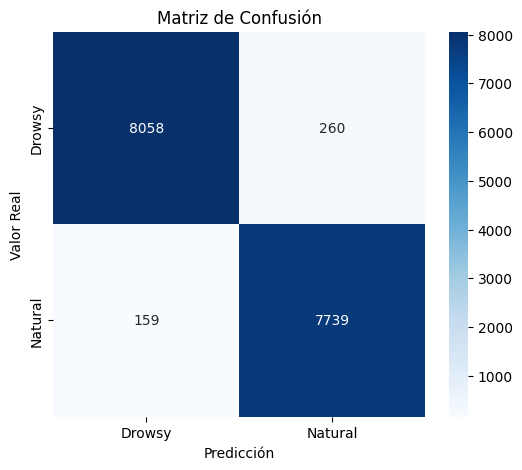

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Drowsy', 'Natural'],
    yticklabels=['Drowsy', 'Natural']
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

# 16. Guardar Modelo

In [23]:
model.save(
    "drowsiness_cnn_unified.keras"
)